# CICIDS2017 — RF + XGBoost Ensemble Training
### 46 features, 5 classes: Normal Traffic, DoS, DDoS, Brute Force, Port Scan
Run on Kaggle with `cicids2017_preprocessed.csv` uploaded as a dataset.

In [66]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# Paths — update if running locally
DATA_PATH   = r'D:\Academic\ML\ModelTraining\Preprocessing\combined.csv'
MODEL_OUT   = r'D:\Academic\ML\ModelTraining\newOutput\ensemble_model.pkl'
SCALER_OUT  = r'D:\Academic\ML\ModelTraining\newOutput\scaler.pkl'
ENCODER_OUT = r'D:\Academic\ML\ModelTraining\newOutput\label_encoder.pkl'

RANDOM_STATE = 42

## 1. Load Data

In [67]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nClass distribution:')
print(df['Attack Type'].value_counts())
print(f'\nFeatures: {df.shape[1] - 1}')

Shape: (1845844, 48)

Class distribution:
Attack Type
Normal Traffic    887162
DoS               390200
DDoS              328605
Port Scan         136633
Brute Force       103244
Name: count, dtype: int64

Features: 47


## 2. Feature / Label Split

In [68]:
feature_cols = [c for c in df.columns if c not in ('Attack Type', 'Source')]
DROP_COLS = [
    'Destination Port',
    'Bwd Packet Length Min',
    'Packet Length Variance',
    'Total Length of Bwd Packets',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
]
feature_cols = [c for c in feature_cols if c not in DROP_COLS]
print(f'Feature columns ({len(feature_cols)}):')
for i, c in enumerate(feature_cols):
    print(f'  {i+1:2d}. {c}')
X = df[feature_cols]  # not df[numeric_cols + ['Source']]
# X = df[feature_cols].values
y_raw = df['Attack Type'].values

Feature columns (40):
   1. Flow Duration
   2. Total Fwd Packets
   3. Total Backward Packets
   4. Total Length of Fwd Packets
   5. Fwd Packet Length Max
   6. Fwd Packet Length Min
   7. Fwd Packet Length Mean
   8. Fwd Packet Length Std
   9. Bwd Packet Length Max
  10. Bwd Packet Length Mean
  11. Bwd Packet Length Std
  12. Flow Bytes/s
  13. Flow Packets/s
  14. Flow IAT Mean
  15. Flow IAT Std
  16. Flow IAT Max
  17. Flow IAT Min
  18. Fwd IAT Std
  19. Fwd IAT Min
  20. Bwd IAT Total
  21. Bwd IAT Std
  22. Bwd IAT Max
  23. Bwd IAT Min
  24. Fwd Header Length
  25. Bwd Header Length
  26. Bwd Packets/s
  27. Min Packet Length
  28. Max Packet Length
  29. Packet Length Mean
  30. Packet Length Std
  31. FIN Flag Count
  32. RST Flag Count
  33. PSH Flag Count
  34. ACK Flag Count
  35. Init_Win_bytes_forward
  36. Init_Win_bytes_backward
  37. act_data_pkt_fwd
  38. min_seg_size_forward
  39. Active Max
  40. Idle Mean


## 3. Label Encoding

In [69]:
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f'Classes: {list(le.classes_)}')
print(f'Encoded: {list(range(len(le.classes_)))}')

joblib.dump(le, ENCODER_OUT)
print(f'Saved: {ENCODER_OUT}')

Classes: ['Brute Force', 'DDoS', 'DoS', 'Normal Traffic', 'Port Scan']
Encoded: [0, 1, 2, 3, 4]
Saved: D:\Academic\ML\ModelTraining\newOutput\label_encoder.pkl


## 4. Train / Test Split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Verify stratification
unique, counts = np.unique(y_train, return_counts=True)
print('\nTrain class distribution:')
for cls, cnt in zip(le.classes_, counts):
    print(f'  {cls}: {cnt:,}')

Train: (1107506, 40), Test: (738338, 40)

Train class distribution:
  Brute Force: 61,946
  DDoS: 197,163
  DoS: 234,120
  Normal Traffic: 532,297
  Port Scan: 81,980


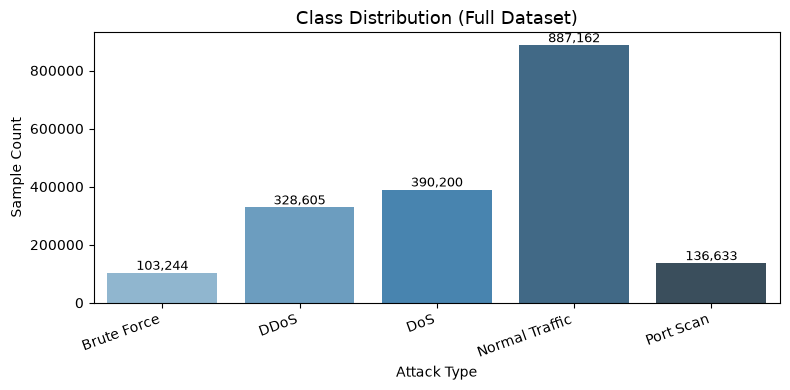

In [71]:
fig, ax = plt.subplots(figsize=(8, 4))
class_counts = pd.Series(
    [(y_train == i).sum() + (y_test == i).sum() for i in range(len(le.classes_))],
    index=le.classes_
)
sns.barplot(x=class_counts.index, y=class_counts.values, palette='Blues_d', ax=ax)
ax.set_title('Class Distribution (Full Dataset)', fontsize=13)
ax.set_xlabel('Attack Type')
ax.set_ylabel('Sample Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Scaling

In [72]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, SCALER_OUT)
print(f'Saved: {SCALER_OUT}')

Saved: D:\Academic\ML\ModelTraining\newOutput\scaler.pkl


## 5b. Feature Weighting


In [73]:
## 5b. Feature Weighting
# Multiply scaled features by importance-based weights so the model
# treats discriminative features as stronger signals.
# Tiers are based on RF importance scores from the preprocessing notebook.

high_importance = [
    'Bwd Packet Length Mean', 'Packet Length Std', 'Bwd Packet Length Std',
    'Max Packet Length', 'Fwd Packet Length Max',
    'Packet Length Mean', 'Total Length of Fwd Packets',
    'Bwd Packet Length Max',
]
medium_importance = [
    'Fwd Header Length', 'Fwd Packet Length Mean', 'Idle Mean', 'Flow IAT Max',
    'Flow IAT Std', 'Total Fwd Packets', 'act_data_pkt_fwd', 'Fwd IAT Std',
    'Init_Win_bytes_backward', 'Flow Duration', 'Bwd Header Length',
    'min_seg_size_forward', 'PSH Flag Count',
]

feature_weights = np.ones(len(feature_cols))
for i, col in enumerate(feature_cols):
    if col in high_importance:
        feature_weights[i] = 3.0
    elif col in medium_importance:
        feature_weights[i] = 2.0

X_train_scaled = X_train_scaled * feature_weights
X_test_scaled  = X_test_scaled  * feature_weights

print('Feature weights applied:')
for col, w in sorted(zip(feature_cols, feature_weights), key=lambda x: -x[1]):
    if w > 1.0:
        print(f'  {col}: {w}')
print(f'  (all others): 1.0')


Feature weights applied:
  Total Length of Fwd Packets: 3.0
  Fwd Packet Length Max: 3.0
  Bwd Packet Length Max: 3.0
  Bwd Packet Length Mean: 3.0
  Bwd Packet Length Std: 3.0
  Max Packet Length: 3.0
  Packet Length Mean: 3.0
  Packet Length Std: 3.0
  Flow Duration: 2.0
  Total Fwd Packets: 2.0
  Fwd Packet Length Mean: 2.0
  Flow IAT Std: 2.0
  Flow IAT Max: 2.0
  Fwd IAT Std: 2.0
  Fwd Header Length: 2.0
  Bwd Header Length: 2.0
  PSH Flag Count: 2.0
  Init_Win_bytes_backward: 2.0
  act_data_pkt_fwd: 2.0
  min_seg_size_forward: 2.0
  Idle Mean: 2.0
  (all others): 1.0


## 6. Compute Sample Weights
Handles class imbalance for both RF and XGBoost.

In [74]:
# sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
# print(f'Sample weight range: {sample_weights.min():.4f} — {sample_weights.max():.4f}')

# # Show effective weight per class
# for cls_idx, cls_name in enumerate(le.classes_):
#     mask = y_train == cls_idx
#     print(f'  {cls_name}: weight = {sample_weights[mask].mean():.4f}')

In [75]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# 1. Compute original balanced weights per class index
classes = np.unique(y_train)
balanced_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# 2. Map class index to its newly adjusted weight
# Example adjustments: Normal Traffic x 0.8 (decrease), all attack classes x 1.25 (increase)
manual_class_weights = {}
for cls_idx, cls_name in enumerate(le.classes_):
    if cls_name == 'Normal Traffic':
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 0.9
    elif cls_name == 'Brute Force':
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 3.0  # highest boost
    elif cls_name == 'DoS' or cls_name == 'DDoS':
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 1.5  # these overlap, moderate boost
    else:
        manual_class_weights[cls_idx] = balanced_weights[cls_idx] * 3.0
# 3. Compute final sample weights using your modified class weights
sample_weights = compute_sample_weight(class_weight=manual_class_weights, y=y_train)

# 4. Print results to verify
print(f'Sample weight range: {sample_weights.min():.4f} — {sample_weights.max():.4f}')
for cls_idx, cls_name in enumerate(le.classes_):
    mask = y_train == cls_idx
    print(f'  {cls_name}: weight = {sample_weights[mask].mean():.4f}')

Sample weight range: 0.3745 — 10.7271
  Brute Force: weight = 10.7271
  DDoS: weight = 1.6852
  DoS: weight = 1.4192
  Normal Traffic: weight = 0.3745
  Port Scan: weight = 8.1057


## 7. Train Random Forest

In [76]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    max_features=0.4,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train_scaled, y_train,sample_weight=sample_weights)
print('RF training complete.')

rf_train_acc = rf.score(X_train_scaled, y_train)
rf_test_acc  = rf.score(X_test_scaled,  y_test)
print(f'RF Train Accuracy: {rf_train_acc:.4f}')
print(f'RF Test  Accuracy: {rf_test_acc:.4f}')

RF training complete.
RF Train Accuracy: 0.9924
RF Test  Accuracy: 0.9924


## 8. Train XGBoost
Trained separately with sample_weight — fixes the VotingClassifier bug
where sample weights are not routed to internal estimators.

In [77]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.2,
    subsample=0.8,
    colsample_bytree=0.5,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=1
)
# Pass sample_weight directly — this is the fix for the imbalance bug
xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights,
        eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
        verbose=20)
print('XGBoost training complete.')

xgb_train_acc = xgb.score(X_train_scaled, y_train)
xgb_test_acc  = xgb.score(X_test_scaled,  y_test)
print(f'XGB Train Accuracy: {xgb_train_acc:.4f}')
print(f'XGB Test  Accuracy: {xgb_test_acc:.4f}')

[0]	validation_0-mlogloss:1.42534	validation_1-mlogloss:1.42521
[20]	validation_0-mlogloss:0.07975	validation_1-mlogloss:0.07921
[40]	validation_0-mlogloss:0.01662	validation_1-mlogloss:0.01639
[60]	validation_0-mlogloss:0.00742	validation_1-mlogloss:0.00741
[80]	validation_0-mlogloss:0.00450	validation_1-mlogloss:0.00461
[100]	validation_0-mlogloss:0.00315	validation_1-mlogloss:0.00334
[120]	validation_0-mlogloss:0.00250	validation_1-mlogloss:0.00275
[140]	validation_0-mlogloss:0.00212	validation_1-mlogloss:0.00242
[160]	validation_0-mlogloss:0.00184	validation_1-mlogloss:0.00219
[180]	validation_0-mlogloss:0.00168	validation_1-mlogloss:0.00207
[199]	validation_0-mlogloss:0.00156	validation_1-mlogloss:0.00198
XGBoost training complete.
XGB Train Accuracy: 0.9997
XGB Test  Accuracy: 0.9996


## 9. Build Soft-Voting Ensemble
Uses pre-fitted estimators — VotingClassifier is set to use them as-is.

In [78]:
from sklearn.preprocessing import LabelEncoder as SklearnLE
from sklearn.utils.multiclass import unique_labels

# Manually construct a minimal internal LabelEncoder that maps 0-4 to 0-4
internal_le = SklearnLE()
internal_le.fit(np.array(list(range(len(le.classes_)))))

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft'
)
ensemble.estimators_ = [rf, xgb]
ensemble.le_ = internal_le
ensemble.classes_ = np.array(list(range(len(le.classes_))))
ensemble.named_estimators_ = {'rf': rf, 'xgb': xgb}

ensemble_test_acc = ensemble.score(X_test_scaled, y_test)
print(f'Ensemble Test Accuracy: {ensemble_test_acc:.4f}')

joblib.dump(ensemble, MODEL_OUT)
print(f'Saved: {MODEL_OUT}')

Ensemble Test Accuracy: 0.9993
Saved: D:\Academic\ML\ModelTraining\newOutput\ensemble_model.pkl


## 10. Classification Report

In [79]:
y_pred = ensemble.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

                precision    recall  f1-score   support

   Brute Force     0.9993    0.9999    0.9996     41298
          DDoS     0.9999    0.9999    0.9999    131442
           DoS     0.9977    0.9996    0.9986    156080
Normal Traffic     0.9998    0.9989    0.9993    354865
     Port Scan     0.9995    0.9995    0.9995     54653

      accuracy                         0.9993    738338
     macro avg     0.9992    0.9995    0.9994    738338
  weighted avg     0.9993    0.9993    0.9993    738338



In [80]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print("\nRow = True, Col = Predicted")
print(cm_df)
# DoS-DDoS off-diagonal specifically
dos_idx = list(le.classes_).index('DoS')
ddos_idx = list(le.classes_).index('DDoS')
print(f"\nDoS predicted as DDoS: {cm[dos_idx][ddos_idx]}")
print(f"DDoS predicted as DoS: {cm[ddos_idx][dos_idx]}")


Row = True, Col = Predicted
                Brute Force    DDoS     DoS  Normal Traffic  Port Scan
Brute Force           41292       0       1               5          0
DDoS                      0  131425       0              17          0
DoS                      17       0  156010              52          1
Normal Traffic           10      18     339          354474         24
Port Scan                 0       0      18              10      54625

DoS predicted as DDoS: 0
DDoS predicted as DoS: 0


## 11. Confusion Matrix

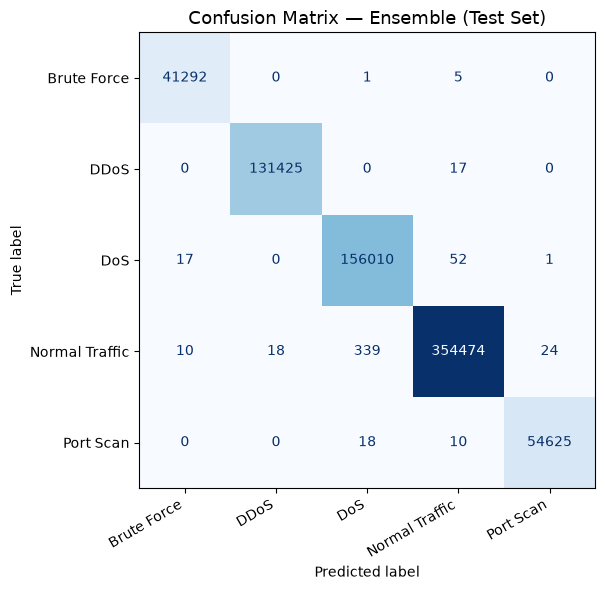

In [81]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Ensemble (Test Set)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\confusion_matrix.png', bbox_inches='tight')
plt.show()

## 12. Per-Model Comparison

In [82]:
from sklearn.metrics import f1_score

rf_pred  = rf.predict(X_test_scaled)
xgb_pred = xgb.predict(X_test_scaled)
ens_pred = y_pred

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Ensemble'],
    'Test Accuracy': [
        rf.score(X_test_scaled, y_test),
        xgb.score(X_test_scaled, y_test),
        ensemble.score(X_test_scaled, y_test)
    ],
    'Macro F1': [
        f1_score(y_test, rf_pred,  average='macro'),
        f1_score(y_test, xgb_pred, average='macro'),
        f1_score(y_test, ens_pred, average='macro')
    ],
    'Weighted F1': [
        f1_score(y_test, rf_pred,  average='weighted'),
        f1_score(y_test, xgb_pred, average='weighted'),
        f1_score(y_test, ens_pred, average='weighted')
    ]
})
print(results.to_string(index=False))

        Model  Test Accuracy  Macro F1  Weighted F1
Random Forest       0.992433  0.994264     0.992440
      XGBoost       0.999569  0.999543     0.999569
     Ensemble       0.999307  0.999389     0.999307


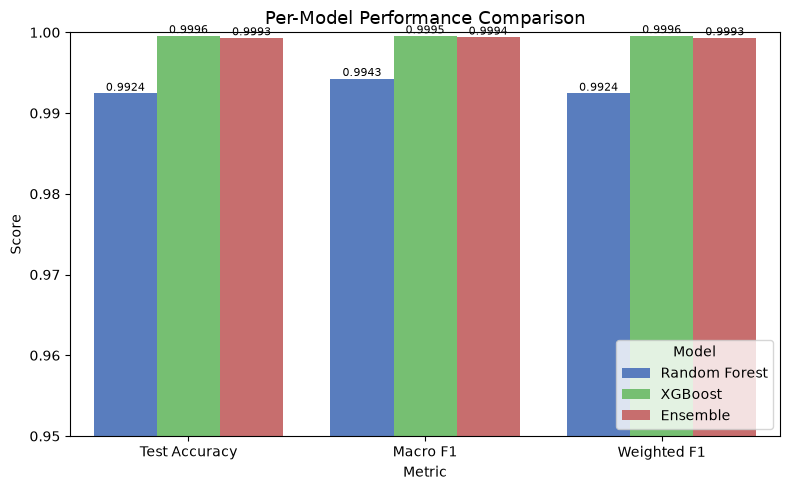

In [83]:
metrics_df = results.melt(id_vars='Model', value_vars=['Test Accuracy', 'Macro F1', 'Weighted F1'],
                           var_name='Metric', value_name='Score')
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model',
            palette=['#4878CF', '#6ACC65', '#D65F5F'], ax=ax)
ax.set_title('Per-Model Performance Comparison', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0.95, 1.0)
ax.legend(title='Model', loc='lower right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

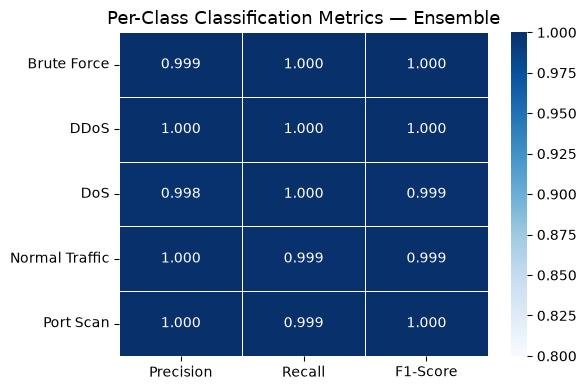

In [84]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).T.loc[le.classes_, ['precision', 'recall', 'f1-score']]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(report_df.astype(float), annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0.8, vmax=1.0)
ax.set_title('Per-Class Classification Metrics — Ensemble', fontsize=13)
ax.set_xticklabels(['Precision', 'Recall', 'F1-Score'])
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\classification_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Feature Importance (RF)

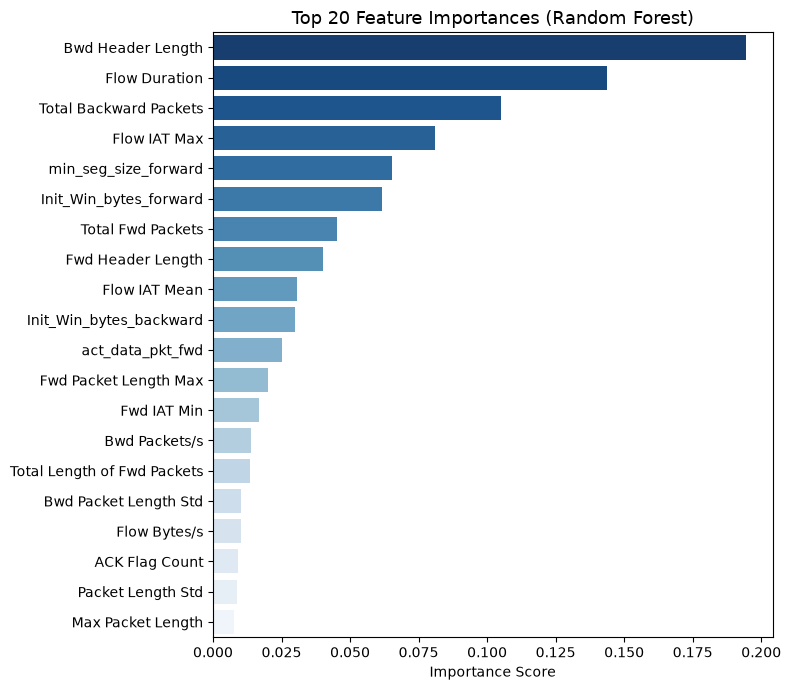

In [85]:
top_n = 20
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_features = importances.head(top_n)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r', ax=ax)
ax.set_title(f'Top {top_n} Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\newOutput\feature_importance_top20.png', dpi=300, bbox_inches='tight')
plt.show()

In [86]:
anova_top10 = [
    'Fwd Packet Length Max', 'Fwd Packet Length Std', 'Bwd Header Length',
    'Fwd Header Length', 'Idle Mean', 'Total Fwd Packets',
    'Flow IAT Max', 'Flow Duration', 'Fwd IAT Std', 'Total Backward Packets'
]
top_n = importances.head(20).index.tolist()
overlap = [f for f in anova_top10 if f in top_n]
print(f"ANOVA top-10 features also in RF top-20: {len(overlap)}/10")
print(overlap)

ANOVA top-10 features also in RF top-20: 7/10
['Fwd Packet Length Max', 'Bwd Header Length', 'Fwd Header Length', 'Total Fwd Packets', 'Flow IAT Max', 'Flow Duration', 'Total Backward Packets']


## 14. Verify Saved Artifacts

In [89]:
# Reload and do a quick sanity check
loaded_model   = joblib.load(MODEL_OUT)
loaded_scaler  = joblib.load(SCALER_OUT)
loaded_encoder = joblib.load(ENCODER_OUT)

# Single sample prediction
sample_raw     = X_test[0:1]
sample_scaled  = loaded_scaler.transform(sample_raw)
pred_encoded   = loaded_model.predict(sample_scaled)
pred_label     = loaded_encoder.inverse_transform(pred_encoded)
pred_proba     = loaded_model.predict_proba(sample_scaled)

print(f'Sample prediction: {pred_label[0]}')
print(f'True label:        {loaded_encoder.inverse_transform([y_test[0]])[0]}')
print(f'\nClass probabilities:')
for cls, prob in zip(loaded_encoder.classes_, pred_proba[0]):
    print(f'  {cls}: {prob:.4f}')

Sample prediction: Normal Traffic
True label:        Normal Traffic

Class probabilities:
  Brute Force: 0.0002
  DDoS: 0.0001
  DoS: 0.0001
  Normal Traffic: 0.9994
  Port Scan: 0.0001
